# Preparación del modelo de memorias RAM

En este notebook se prepararán los datos limpios de RAM para crear grupos de productos parecidos.

Los datos se obtendrán desde PostgreSQL. Se utilizarán el precio, la capacidad, la frecuencia, la latencia, el tipo de memoria y la marca.

In [ ]:
# CELDA 1: CONEXIÓN A POSTGRESQL


import pandas as pd
import psycopg


password = input("Contraseña PostgreSQL: ")

conn = psycopg.connect(
    dbname="pccomponentes_ml",
    user="postgres",
    password=password,
    host="localhost",
    port=5432,
)

conn.execute("SET TRANSACTION READ ONLY")

print("Conexión de solo lectura creada correctamente")

Conexión de solo lectura creada correctamente


## 2. Carga de los datos para el modelo

In [3]:
# CELDA 2: CONSULTA DE DATOS RAM

def consultar_dataframe(consulta):
    with conn.cursor() as cursor:
        cursor.execute(consulta)

        columnas = [
            columna.name
            for columna in cursor.description
        ]

        registros = cursor.fetchall()

    return pd.DataFrame(registros, columns=columnas)


datos_ram = consultar_dataframe("""
    SELECT
        p.producto_id,
        p.nombre,
        p.marca,
        p.precio,
        e.tipo_memoria,
        e.capacidad_gb,
        e.frecuencia_mhz,
        e.latencia_cl
    FROM productos AS p
    INNER JOIN especificaciones_ram AS e
        ON p.producto_id = e.producto_id
    WHERE p.categoria = 'memoria_ram'
    ORDER BY p.producto_id;
""")


print("Productos cargados:", len(datos_ram))

display(datos_ram.head())

Productos cargados: 1574


,producto_id,nombre,marca,precio,tipo_memoria,capacidad_gb,frecuencia_mhz,latencia_cl
0,ram_0001,Forgeon Cyclone PRO DDR5 6000 MHz 32 GB 2x16GB...,Forgeon,449.95,DDR5,32.00,6000.0,30.0
1,ram_0002,Forgeon Cyclone PLUS V2 DDR4 3200 MHz 16GB 2x8...,Forgeon,139.95,DDR4,16.00,3200.0,16.0
2,ram_0003,Acer Predator Pallas II DDR5 6000MHz 32GB 2x16...,Acer,409.95,DDR5,32.00,6000.0,34.0
3,ram_0004,Memoria RAM Acer Predator PALLASII 32GB 2x16GB...,Acer,379.95,DDR5,32.00,6000.0,34.0
4,ram_0005,Forgeon Cyclone PLUS V2 DDR4 3200 MHz 32GB 2x1...,Forgeon,249.95,DDR4,32.00,3200.0,16.0


## 3. Revisión de los datos

In [4]:
# CELDA 3: REVISIÓN DE VALORES NULOS

print("Tipos de datos:")
print(datos_ram.dtypes)

print("\nValores nulos:")
print(datos_ram.isna().sum())

Tipos de datos:
producto_id           str
nombre                str
marca                 str
precio             object
tipo_memoria          str
capacidad_gb       object
frecuencia_mhz    float64
latencia_cl       float64
dtype: object

Valores nulos:
producto_id         0
nombre              0
marca              81
precio              0
tipo_memoria       87
capacidad_gb       54
frecuencia_mhz     62
latencia_cl       279
dtype: int64


## 4. Preparación de los valores

### Variables utilizadas

Para crear los grupos se utilizarán el precio, la capacidad, la frecuencia, la latencia y el tipo de memoria.

La marca se mantendrá para revisar los resultados, pero no se utilizará para crear los grupos. Hay muchas marcas diferentes y podrían tener demasiado peso en el resultado.

In [5]:
# CELDA 4: CONVERSIÓN Y VALORES NULOS

datos_modelo = datos_ram.copy()

columnas_numericas = [
    "precio",
    "capacidad_gb",
    "frecuencia_mhz",
    "latencia_cl",
]

for columna in columnas_numericas:
    datos_modelo[columna] = pd.to_numeric(
        datos_modelo[columna],
        errors="coerce",
    )

    datos_modelo[columna] = datos_modelo[columna].fillna(
        datos_modelo[columna].median()
    )


datos_modelo["marca"] = datos_modelo["marca"].fillna(
    "Sin identificar"
)

datos_modelo["tipo_memoria"] = (
    datos_modelo["tipo_memoria"]
    .fillna("Sin identificar")
)


columnas_modelo = columnas_numericas + ["tipo_memoria"]

assert datos_modelo[columnas_modelo].isna().sum().sum() == 0

print(datos_modelo[columnas_modelo].isna().sum())

display(datos_modelo[columnas_modelo].head())

precio            0
capacidad_gb      0
frecuencia_mhz    0
latencia_cl       0
tipo_memoria      0
dtype: int64


,precio,capacidad_gb,frecuencia_mhz,latencia_cl,tipo_memoria
0,449.95,32.0,6000.0,30.0,DDR5
1,139.95,16.0,3200.0,16.0,DDR4
2,409.95,32.0,6000.0,34.0,DDR5
3,379.95,32.0,6000.0,34.0,DDR5
4,249.95,32.0,3200.0,16.0,DDR4


## 5. Transformación de las variables

In [6]:
# CELDA 5: TRANSFORMACIÓN DE LAS VARIABLES

from sklearn.preprocessing import StandardScaler


variables_numericas = [
    "precio",
    "capacidad_gb",
    "frecuencia_mhz",
    "latencia_cl",
]

escalador = StandardScaler()

datos_numericos = pd.DataFrame(
    escalador.fit_transform(
        datos_modelo[variables_numericas]
    ),
    columns=variables_numericas,
    index=datos_modelo.index,
)


tipo_memoria = pd.get_dummies(
    datos_modelo["tipo_memoria"],
    prefix="tipo",
    dtype=int,
)


X = pd.concat(
    [datos_numericos, tipo_memoria],
    axis=1,
)


assert X.isna().sum().sum() == 0

print("Filas y columnas del modelo:", X.shape)

display(X.head())

Filas y columnas del modelo: (1574, 8)


,precio,capacidad_gb,frecuencia_mhz,latencia_cl,tipo_DDR3,tipo_DDR4,tipo_DDR5,tipo_Sin identificar
0,-0.175779,0.134826,0.953291,0.127562,0,0,1,0
1,-0.668493,-0.593851,-0.781110,-1.248334,0,1,0,0
2,-0.239355,0.134826,0.953291,0.520675,0,0,1,0
3,-0.287037,0.134826,0.953291,0.520675,0,0,1,0
4,-0.493659,0.134826,-0.781110,-1.248334,0,1,0,0


## 6. Elección del número de grupos

,grupos,distancia_interna,silhouette
0,2,3688.975366,0.497226
1,3,2587.839733,0.489943
2,4,2217.361017,0.479825
3,5,1910.697795,0.451526
4,6,1731.932602,0.417471
5,7,1582.752047,0.387758
6,8,1408.516636,0.351238


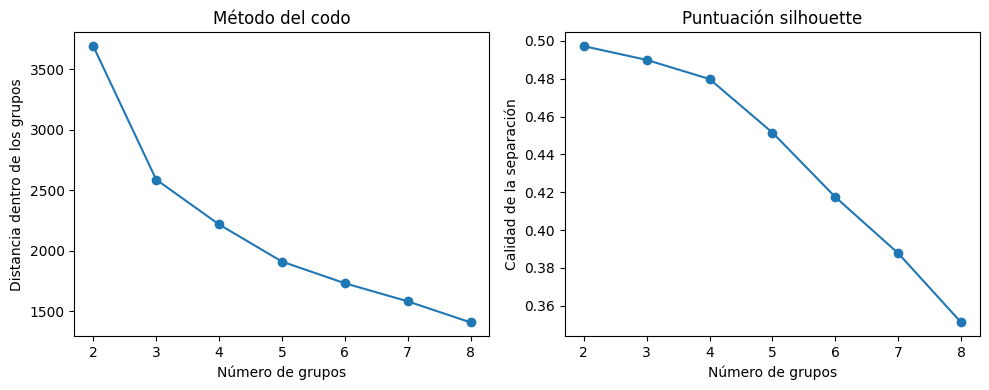

In [7]:
# CELDA 6: COMPARACIÓN DEL NÚMERO DE GRUPOS

import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


resultados = []

for numero_grupos in range(2, 9):
    modelo = KMeans(
        n_clusters=numero_grupos,
        random_state=42,
        n_init=10,
    )

    grupos = modelo.fit_predict(X)

    resultados.append({
        "grupos": numero_grupos,
        "distancia_interna": modelo.inertia_,
        "silhouette": silhouette_score(X, grupos),
    })


resultados = pd.DataFrame(resultados)

display(resultados)


plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(
    resultados["grupos"],
    resultados["distancia_interna"],
    marker="o",
)
plt.title("Método del codo")
plt.xlabel("Número de grupos")
plt.ylabel("Distancia dentro de los grupos")

plt.subplot(1, 2, 2)
plt.plot(
    resultados["grupos"],
    resultados["silhouette"],
    marker="o",
)
plt.title("Puntuación silhouette")
plt.xlabel("Número de grupos")
plt.ylabel("Calidad de la separación")

plt.tight_layout()
plt.show()

### Número de grupos elegido

Se utilizarán 3 grupos. El método del codo muestra una mejora clara hasta ese punto y la separación entre grupos sigue siendo buena.

In [8]:
# CELDA 7: MODELO FINAL CON 3 GRUPOS

modelo_final = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10,
)

datos_modelo["grupo"] = modelo_final.fit_predict(X)

print("Productos por grupo:")
print(
    datos_modelo["grupo"]
    .value_counts()
    .sort_index()
)

Productos por grupo:
grupo
0    653
1    681
2    240
Name: count, dtype: int64


## 7. Análisis de los grupos

In [9]:
# CELDA 8: CARACTERÍSTICAS DE LOS GRUPOS

resumen_grupos = (
    datos_modelo
    .groupby("grupo")[variables_numericas]
    .median()
    .round(2)
)

resumen_grupos.insert(
    0,
    "productos",
    datos_modelo["grupo"].value_counts().sort_index(),
)


tipos_por_grupo = pd.crosstab(
    datos_modelo["grupo"],
    datos_modelo["tipo_memoria"],
)


print("Características de cada grupo:")
display(resumen_grupos)

print("Tipos de memoria por grupo:")
display(tipos_por_grupo)

Características de cada grupo:


,productos,precio,capacidad_gb,frecuencia_mhz,latencia_cl
grupo,,,,,
0,653,489.27,32.0,5600.0,36.0
1,681,170.20,16.0,3200.0,18.0
2,240,1319.68,64.0,6000.0,32.0


Tipos de memoria por grupo:


tipo_memoria,DDR3,DDR4,DDR5,Sin identificar
grupo,,,,
0,0,2,605,46
1,83,564,1,33
2,0,14,218,8


### Descripción de los grupos

- **Grupo 0 - DDR5 estándar:** productos DDR5 con capacidad y precio intermedios.
- **Grupo 1 - RAM básica:** productos principalmente DDR4 y DDR3, con menor capacidad y precio.
- **Grupo 2 - DDR5 de alta capacidad:** productos DDR5 con más capacidad, frecuencia y precio.

In [10]:
# CELDA 9: NOMBRES DE LOS GRUPOS

nombres_grupos = {
    0: "DDR5 estándar",
    1: "RAM básica",
    2: "DDR5 de alta capacidad",
}

datos_modelo["nombre_grupo"] = (
    datos_modelo["grupo"]
    .map(nombres_grupos)
)

print(
    datos_modelo["nombre_grupo"]
    .value_counts()
)

nombre_grupo
RAM básica                681
DDR5 estándar             653
DDR5 de alta capacidad    240
Name: count, dtype: int64


## 8. Visualización de los grupos

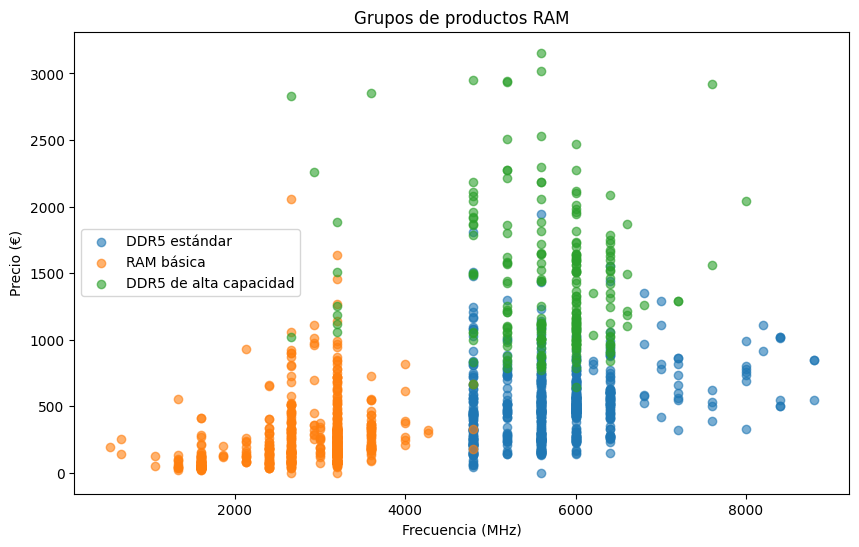

In [11]:
# CELDA 10: GRÁFICA DE LOS GRUPOS

limite_precio = datos_modelo["precio"].quantile(0.99)

datos_grafica = datos_modelo[
    datos_modelo["precio"] <= limite_precio
]


plt.figure(figsize=(10, 6))

for nombre_grupo in nombres_grupos.values():
    grupo = datos_grafica[
        datos_grafica["nombre_grupo"] == nombre_grupo
    ]

    plt.scatter(
        grupo["frecuencia_mhz"],
        grupo["precio"],
        label=nombre_grupo,
        alpha=0.6,
    )


plt.title("Grupos de productos RAM")
plt.xlabel("Frecuencia (MHz)")
plt.ylabel("Precio (€)")
plt.legend()

plt.show()


### Lectura de la gráfica

Los tres grupos muestran diferencias claras de frecuencia y precio. Algunos productos aparecen cerca de otros grupos porque el modelo también tiene en cuenta la capacidad, la latencia y el tipo de memoria.

In [12]:
# CELDA 11: EJEMPLOS DE CADA GRUPO

columnas_muestra = [
    "nombre",
    "marca",
    "precio",
    "capacidad_gb",
    "frecuencia_mhz",
    "tipo_memoria",
    "nombre_grupo",
]

for nombre_grupo in nombres_grupos.values():
    print("\n", nombre_grupo)

    display(
        datos_modelo[
            datos_modelo["nombre_grupo"] == nombre_grupo
        ][columnas_muestra].head(5)
    )


 DDR5 estándar


,nombre,marca,precio,capacidad_gb,frecuencia_mhz,tipo_memoria,nombre_grupo
0,Forgeon Cyclone PRO DDR5 6000 MHz 32 GB 2x16GB...,Forgeon,449.95,32.0,6000.0,DDR5,DDR5 estándar
2,Acer Predator Pallas II DDR5 6000MHz 32GB 2x16...,Acer,409.95,32.0,6000.0,DDR5,DDR5 estándar
3,Memoria RAM Acer Predator PALLASII 32GB 2x16GB...,Acer,379.95,32.0,6000.0,DDR5,DDR5 estándar
5,Corsair Vengeance DDR5 6000MHz 32 GB 2x16GB CL...,Corsair,453.99,32.0,6000.0,DDR5,DDR5 estándar
6,Forgeon Cyclone PRO RGB DDR5 6000 MHz 32GB 2x1...,Forgeon,479.95,32.0,6000.0,DDR5,DDR5 estándar



 RAM básica


,nombre,marca,precio,capacidad_gb,frecuencia_mhz,tipo_memoria,nombre_grupo
1,Forgeon Cyclone PLUS V2 DDR4 3200 MHz 16GB 2x8...,Forgeon,139.95,16.0,3200.0,DDR4,RAM básica
4,Forgeon Cyclone PLUS V2 DDR4 3200 MHz 32GB 2x1...,Forgeon,249.95,32.0,3200.0,DDR4,RAM básica
11,Kingston FURY Beast DDR4 3200 MHz 16GB 2x8GB CL16,Kingston,156.95,16.0,3200.0,DDR4,RAM básica
12,Kingston FURY Beast DDR4 3200 MHz 8GB CL16,Kingston,79.95,8.0,3200.0,DDR4,RAM básica
13,Corsair Vengeance LPX DDR4 3200MHz PC4-25600 3...,Corsair,260.98,32.0,3200.0,DDR4,RAM básica



 DDR5 de alta capacidad


,nombre,marca,precio,capacidad_gb,frecuencia_mhz,tipo_memoria,nombre_grupo
45,Kingston FURY Beast DDR5 6000MHz 64GB 2x32GB C...,Kingston,999.95,64.0,6000.0,DDR5,DDR5 de alta capacidad
68,Memoria RAM Corsair Vengeance RGB CMH64GX5M2D6...,Corsair,784.95,64.0,6000.0,DDR5,DDR5 de alta capacidad
69,Memoria RAM Kingston 64GB DDR5 6000MT/s FURY B...,Kingston,993.01,64.0,6000.0,DDR5,DDR5 de alta capacidad
71,Memoria RAM G.Skill 64GB DDR5 6000MHz Trident ...,G.Skill,969.00,64.0,6000.0,DDR5,DDR5 de alta capacidad
89,Memoria RAM GoodRam IR-5600D564L36/64GDC 64GB ...,GoodRam,804.55,64.0,5600.0,DDR5,DDR5 de alta capacidad


### Comprobación de los grupos

Los productos mostrados encajan con las características de cada grupo. La separación obtenida permite analizar los diferentes perfiles de productos RAM.

## 9. Guardado del modelo

El modelo se guardará para poder utilizarlo más adelante desde la API sin tener que entrenarlo de nuevo.

In [13]:
# CELDA 12: GUARDADO DEL MODELO

from pathlib import Path

import joblib


# El notebook está dentro de la carpeta notebooks.
# Con .parent llegamos a la carpeta principal del proyecto.
raiz_proyecto = Path.cwd().parent

# Carpeta donde guardaremos los modelos.
ruta_modelos = raiz_proyecto / "models"

# Crea la carpeta si todavía no existe.
ruta_modelos.mkdir(exist_ok=True)

# Nombre y ruta del archivo.
ruta_modelo = ruta_modelos / "modelo_clustering_ram.joblib"


# Guardamos el modelo y la información necesaria para usarlo.
artefacto_modelo = {
    "modelo": modelo_final,
    "escalador": escalador,
    "variables_numericas": variables_numericas,
    "medianas": {
        columna: datos_modelo[columna].median()
        for columna in variables_numericas
    },
    "columnas_modelo": X.columns.tolist(),
    "nombres_grupos": nombres_grupos,
}


joblib.dump(
    artefacto_modelo,
    ruta_modelo,
)


print("Modelo guardado en:")
print(ruta_modelo)
print("Archivo creado:", ruta_modelo.exists())

Modelo guardado en:
c:\Visual Code\PC_COMPONENTES\pccomponentes-ml-analysis\models\modelo_clustering_ram.joblib
Archivo creado: True


In [14]:
# CELDA 13: COMPROBACIÓN DEL MODELO GUARDADO

modelo_guardado = joblib.load(ruta_modelo)

grupo_prueba = modelo_guardado["modelo"].predict(
    X.iloc[[0]]
)[0]

grupo_esperado = datos_modelo.iloc[0]["grupo"]

assert grupo_prueba == grupo_esperado

print("Grupo obtenido:", grupo_prueba)
print("Comprobación correcta")

Grupo obtenido: 0
Comprobación correcta


## 10. Conclusiones

Se han creado tres grupos de productos RAM a partir del precio, la capacidad, la frecuencia, la latencia y el tipo de memoria.

Los grupos separan productos básicos, productos DDR5 estándar y productos DDR5 de mayor capacidad. Los grupos se han guardado en PostgreSQL para poder consultarlos después desde la API sin ejecutar nuevamente el modelo.

In [15]:
# CELDA 14: CIERRE DE LA CONEXIÓN

conn.close()

print("Conexión cerrada")

Conexión cerrada


## 11. Guardado de los grupos en PostgreSQL

Guardamos el grupo asignado a cada producto para poder consultarlo desde la API sin ejecutar nuevamente el modelo.

In [16]:
# CELDA 15: PREPARACION DE RESULTADOS PARA POSTGRESQL

resultados_cluster = [
    (
        fila.producto_id,
        int(fila.grupo),
        fila.nombre_grupo,
    )
    for fila in datos_modelo[
        ["producto_id", "grupo", "nombre_grupo"]
    ].itertuples(index=False)
]

assert len(resultados_cluster) == datos_modelo["producto_id"].nunique()

print(f"Resultados preparados: {len(resultados_cluster)}")

Resultados preparados: 1574


In [17]:
# CELDA 16: GUARDADO DE RESULTADOS EN POSTGRESQL

password = input("Contraseña PostgreSQL: ")

with psycopg.connect(
    dbname="pccomponentes_ml",
    user="postgres",
    password=password,
    host="localhost",
    port=5432,
) as conn_escritura:
    with conn_escritura.cursor() as cursor:
        cursor.executemany(
            """
            INSERT INTO resultados_clustering_ram (
                producto_id,
                grupo,
                nombre_grupo
            )
            VALUES (%s, %s, %s)
            ON CONFLICT (producto_id) DO UPDATE SET
                grupo = EXCLUDED.grupo,
                nombre_grupo = EXCLUDED.nombre_grupo;
            """,
            resultados_cluster,
        )

print(f"Resultados guardados: {len(resultados_cluster)}")

Resultados guardados: 1574
